In [8]:
!pip install -q pandas scikit-learn matplotlib seaborn

110.96s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [9]:
from pathlib import Path
for p in sorted(Path("/Users/bengeraci/Downloads/mlbdata").rglob("*")):
    print(p)

/Users/bengeraci/Downloads/mlbdata/Teams.csv


In [10]:
TEAMS_CSV = Path("/Users/bengeraci/Downloads/mlbdata/some-subfolder/Teams.csv")

# What Drives MLB Regular Season Wins?
### Comparing Ridge Regression and Random Forest

**Research question:** Which team-level factors (offensive production, pitching, and defense) are the strongest predictors of MLB regular season wins, and do a linear regression model and a random forest model agree on their relative importance?

**Hypothesis:** I expect pitching and on-base skills to outrank defense

**Approach in one paragraph:** I use team-season data from the Lahman Baseball Database, engineer per-game rate statistics for offense, pitching, and defense, and predict each team's wins (scaled to a 162-game season). I train a Ridge regression (interpretable coefficients) and a Random Forest (captures nonlinear effects and interactions) on older seasons and test both on newer seasons. Then I compare their predictive accuracy and their rankings of feature importance.

**Notebook map:** 1. Setup, 2. Data loading, 3. Cleaning and feature engineering, 4. Key variables, 5. Exploratory analysis, 6. Train/test split, 7. Model 1 (Ridge), 8. Model 2 (Random Forest), 9. Model comparison, 10. Conclusion and limitations.

## 1. Setup
Importing all necessary modules

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# ---- Project settings (change these to explore) ----
DATA_DIR = Path("mlbdata")           # keep your CSVs in a data/ folder next to this notebook
TEAMS_CSV = Path("/Users/bengeraci/DS Studio 2/mlbdata/Teams.csv")  # path to Teams.csv (from Lahman database)
FIRST_YEAR = 1998                 # 30-team era begins in 1998
TRAIN_END = 2014                  # train on seasons <= this, test on seasons after it
EXCLUDE_YEARS = [2020]            # 60-game season, not comparable
USE_FANGRAPHS = False             # set True to try the optional pybaseball/FanGraphs section

## 2. Data Loading

**Primary source: Lahman Baseball Database (`Teams` table).** One row = one team in one season, with wins, losses, and full batting, pitching, and fielding totals.

In [12]:
DATA_DIR.mkdir(exist_ok=True)

if TEAMS_CSV.exists():
    teams_raw = pd.read_csv(TEAMS_CSV)
    print(f"Loaded {TEAMS_CSV}")
else:
    raise FileNotFoundError(
        f"Couldn't find {TEAMS_CSV.resolve()}. "
        "Download the CSV version from sabr.org/lahman-database and place Teams.csv there."
    )

print("Shape:", teams_raw.shape)
print("Seasons:", teams_raw["yearID"].min(), "to", teams_raw["yearID"].max())
teams_raw.head()

Loaded /Users/bengeraci/DS Studio 2/mlbdata/Teams.csv
Shape: (3614, 48)
Seasons: 1871 to 2025


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,NaN,BS1,BNA,NaN,3,31,NaN,20,10,...,24.0,0.834,Boston Red Stockings,South End Grounds I,NaN,103.0,98.0,BOS,BS1,BS1
1,1871,NaN,CH1,CNA,NaN,2,28,NaN,19,9,...,16.0,0.829,Chicago White Stockings,Union Base-Ball Grounds,NaN,104.0,102.0,CHI,CH1,CH1
2,1871,NaN,CL1,CFC,NaN,8,29,NaN,10,19,...,15.0,0.818,Cleveland Forest Citys,National Association Grounds,NaN,96.0,100.0,CLE,CL1,CL1
3,1871,NaN,FW1,KEK,NaN,7,19,NaN,7,12,...,8.0,0.803,Fort Wayne Kekiongas,Hamilton Field,NaN,101.0,107.0,KEK,FW1,FW1
4,1871,NaN,NY2,NNA,NaN,5,33,NaN,16,17,...,14.0,0.840,New York Mutuals,Union Grounds (Brooklyn),NaN,90.0,88.0,NYU,NY2,NY2


In [13]:
from pathlib import Path
for p in (Path.home() / "Downloads").rglob("Teams*.csv"):
    print(p)

/Users/bengeraci/Downloads/Teams (1).csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv/Teams.csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv/TeamsFranchises.csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv/TeamsHalf.csv
/Users/bengeraci/Downloads/mlbdata/Teams.csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv 2/Teams.csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv 2/TeamsFranchises.csv
/Users/bengeraci/Downloads/lahman_1871-2024_csv 2/TeamsHalf.csv


## 3. Data Cleaning and Feature Engineering



In [14]:
df = teams_raw[(teams_raw["yearID"] >= FIRST_YEAR) & (~teams_raw["yearID"].isin(EXCLUDE_YEARS))].copy()

# Target: wins scaled to a 162-game season
df["W162"] = df["W"] / df["G"] * 162

# ---- Offense ----
tb = df["H"] + df["2B"] + 2 * df["3B"] + 3 * df["HR"]                      # total bases
df["OBP"] = (df["H"] + df["BB"] + df["HBP"]) / (df["AB"] + df["BB"] + df["HBP"] + df["SF"])
df["SLG"] = tb / df["AB"]
df["HR_pg"] = df["HR"] / df["G"]
df["BB_pg"] = df["BB"] / df["G"]
df["SO_pg"] = df["SO"] / df["G"]
df["SB_pg"] = df["SB"] / df["G"]

# ---- Pitching ----
innings = df["IPouts"] / 3
df["ERA"] = df["ERA"]                                    # already a rate in Lahman
df["WHIP"] = (df["HA"] + df["BBA"]) / innings
df["K9"] = df["SOA"] * 9 / innings
df["BB9"] = df["BBA"] * 9 / innings
df["HRA9"] = df["HRA"] * 9 / innings

# ---- Defense ----
df["FP"] = df["FP"]                                      # fielding percentage (already a rate)
df["DP_pg"] = df["DP"] / df["G"]

# ---- Reference only (NOT used as model features) ----
df["RunDiff"] = df["R"] - df["RA"]

OFFENSE = ["OBP", "SLG", "HR_pg", "BB_pg", "SO_pg", "SB_pg"]
PITCHING = ["ERA", "WHIP", "K9", "BB9", "HRA9"]
DEFENSE = ["FP", "DP_pg"]
FEATURES = OFFENSE + PITCHING + DEFENSE
TARGET = "W162"

# Check for missing values in what we need, then drop incomplete rows
print("Missing values in model columns:")
print(df[FEATURES + [TARGET]].isna().sum()[lambda s: s > 0])
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print("\nRows after cleaning:", len(df))
df[["yearID", "teamID", "W", "W162"] + FEATURES].head()

Missing values in model columns:
Series([], dtype: int64)

Rows after cleaning: 810


,yearID,teamID,W,W162,OBP,SLG,HR_pg,BB_pg,SO_pg,SB_pg,ERA,WHIP,K9,BB9,HRA9,FP,DP_pg
0,1998,ANA,85,85.0,0.335206,0.415453,0.907407,3.148148,6.345679,0.574074,4.49,1.461911,6.799861,3.926593,1.022161,0.983,0.901235
1,1998,ARI,65,65.0,0.313952,0.392825,0.981481,3.018519,7.648148,0.450617,4.63,1.362811,5.705376,3.072609,1.181289,0.984,0.771605
2,1998,ATL,106,106.0,0.341749,0.452772,1.327160,3.382716,6.555556,0.604938,3.25,1.221965,7.707136,2.921455,0.731928,0.985,0.858025
3,1998,BAL,79,79.0,0.346805,0.446900,1.320988,3.660494,5.574074,0.530864,4.74,1.425245,6.696553,3.363996,1.062646,0.987,0.888889
4,1998,BOS,92,92.0,0.347861,0.462596,1.265432,3.339506,6.475309,0.444444,4.18,1.330084,6.424095,3.158774,1.052925,0.983,0.790123


## 4. Key Variables



In [15]:
variable_info = pd.DataFrame([
    ("W162",  "Target", "Wins scaled to 162 games. The outcome we are trying to predict."),
    ("OBP",   "Offense", "How often a team reaches base. Runners are the raw material for runs, and outs are the scarcest resource in baseball."),
    ("SLG",   "Offense", "Power: total bases per at-bat. Extra-base hits turn baserunners into runs."),
    ("HR_pg", "Offense", "Home runs per game. Overlaps with SLG but captures the most valuable single outcome."),
    ("BB_pg", "Offense", "Walks drawn per game. Reflects plate discipline; overlaps with OBP."),
    ("SO_pg", "Offense", "Strikeouts per game (batting). Strikeouts are outs that can't advance runners."),
    ("SB_pg", "Offense", "Stolen bases per game. A small run contributor, included to test whether speed matters."),
    ("ERA",   "Pitching", "Earned runs allowed per nine innings. The most common summary of run prevention."),
    ("WHIP",  "Pitching", "Walks plus hits per inning pitched. Measures baserunners allowed."),
    ("K9",    "Pitching", "Strikeouts per nine innings. Outs that don't depend on defense or luck on balls in play."),
    ("BB9",   "Pitching", "Walks per nine innings. Measures control; free baserunners raise run risk."),
    ("HRA9",  "Pitching", "Home runs allowed per nine innings. Home runs are the most damaging way to give up runs."),
    ("FP",    "Defense", "Fielding percentage. A crude measure of how reliably a defense converts chances."),
    ("DP_pg", "Defense", "Double plays turned per game. Reflects infield defense and pitcher ground-ball tendencies."),
], columns=["variable", "group", "why it matters"])

pd.set_option("display.max_colwidth", None)
variable_info

,variable,group,why it matters
0,W162,Target,Wins scaled to 162 games. The outcome we are trying to predict.
1,OBP,Offense,"How often a team reaches base. Runners are the raw material for runs, and outs are the scarcest resource in baseball."
2,SLG,Offense,Power: total bases per at-bat. Extra-base hits turn baserunners into runs.
3,HR_pg,Offense,Home runs per game. Overlaps with SLG but captures the most valuable single outcome.
4,BB_pg,Offense,Walks drawn per game. Reflects plate discipline; overlaps with OBP.
5,SO_pg,Offense,Strikeouts per game (batting). Strikeouts are outs that can't advance runners.
6,SB_pg,Offense,"Stolen bases per game. A small run contributor, included to test whether speed matters."
7,ERA,Pitching,Earned runs allowed per nine innings. The most common summary of run prevention.
8,WHIP,Pitching,Walks plus hits per inning pitched. Measures baserunners allowed.
9,K9,Pitching,Strikeouts per nine innings. Outs that don't depend on defense or luck on balls in play.


## 5. Exploratory Data Analysis

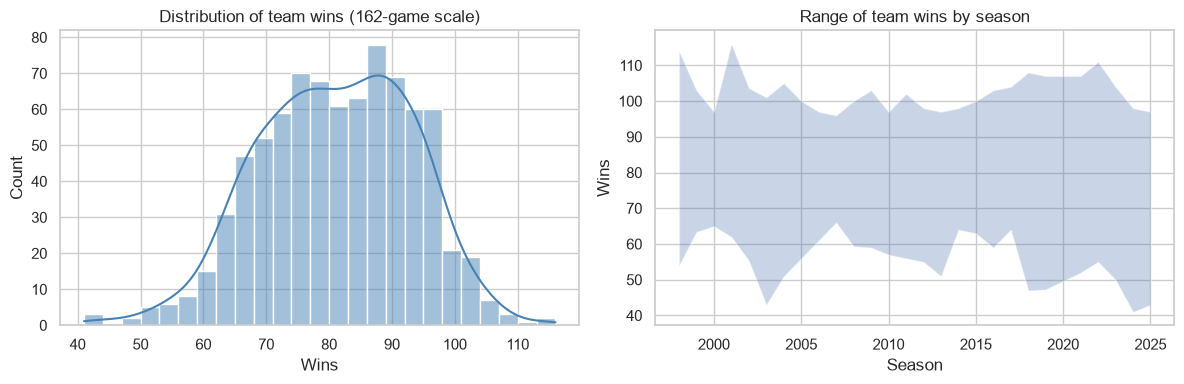

count    810.0
mean      81.0
std       12.1
min       41.0
25%       72.0
50%       81.0
75%       90.0
max      116.0
Name: W162, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=25, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of team wins (162-game scale)")
axes[0].set_xlabel("Wins")

wins_by_year = df.groupby("yearID")[TARGET].agg(["min", "max"])
axes[1].fill_between(wins_by_year.index, wins_by_year["min"], wins_by_year["max"], alpha=0.3)
axes[1].set_title("Range of team wins by season")
axes[1].set_xlabel("Season"); axes[1].set_ylabel("Wins")
plt.tight_layout(); plt.show()

print(df[TARGET].describe().round(1))

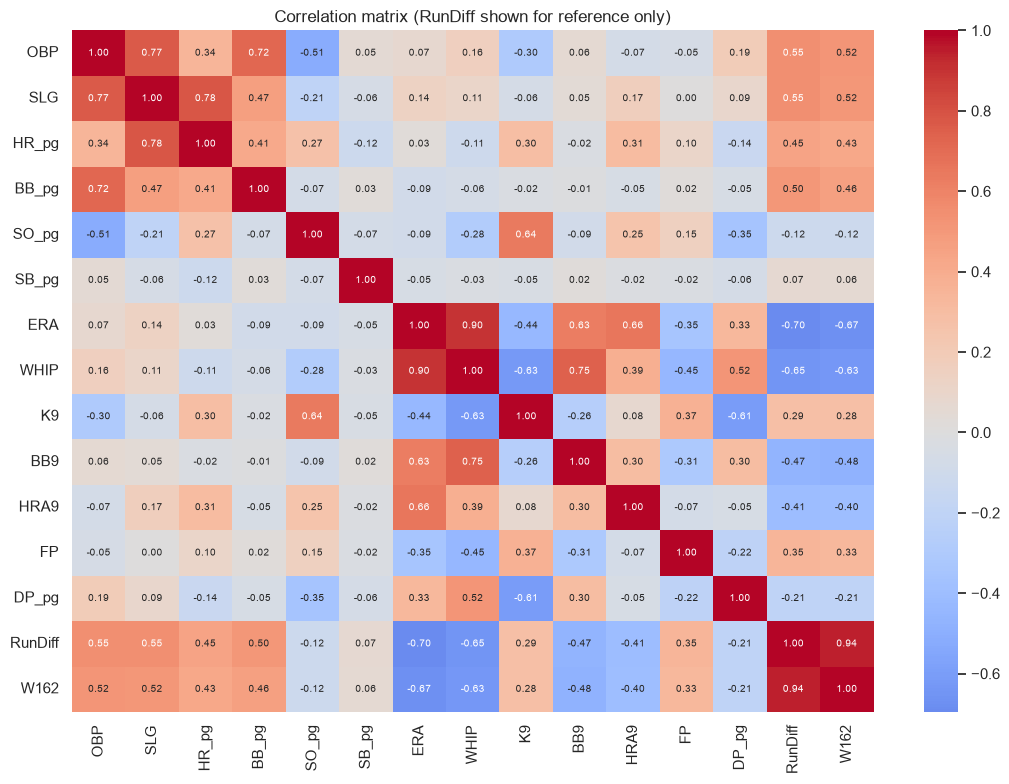

Correlation with wins:
RunDiff    0.943
ERA       -0.674
WHIP      -0.631
OBP        0.517
SLG        0.516
BB9       -0.479
BB_pg      0.464
HR_pg      0.429
HRA9      -0.404
FP         0.334
K9         0.283
DP_pg     -0.208
SO_pg     -0.118
SB_pg      0.059
Name: W162, dtype: float64


In [17]:
corr = df[FEATURES + ["RunDiff", TARGET]].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation matrix (RunDiff shown for reference only)")
plt.tight_layout(); plt.show()

print("Correlation with wins:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))

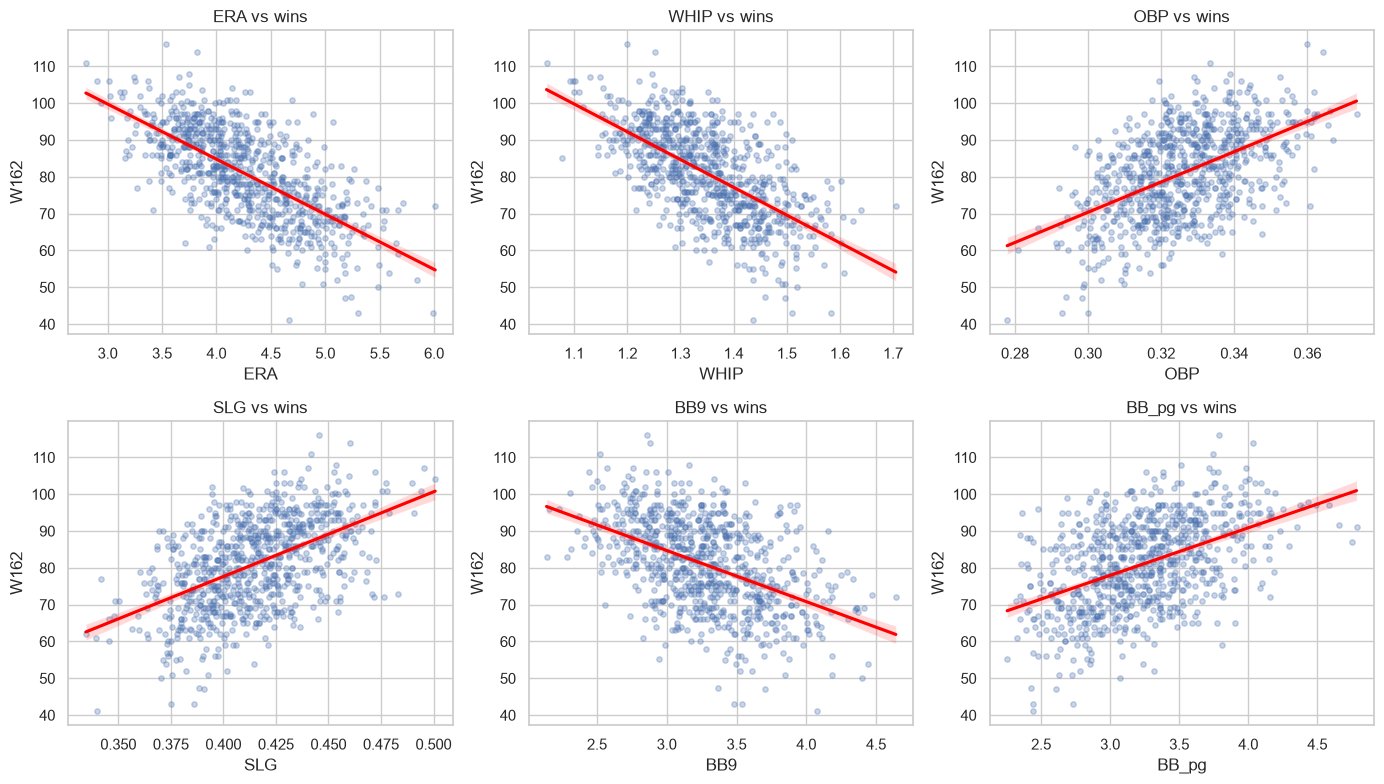

In [18]:
top_feats = corr[TARGET].drop([TARGET, "RunDiff"]).abs().sort_values(ascending=False).index[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), top_feats):
    sns.regplot(data=df, x=feat, y=TARGET, ax=ax, scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
    ax.set_title(f"{feat} vs wins")
plt.tight_layout(); plt.show()

## 6. Train/Test Split

Split **by season**, not randomly. Training on older seasons and testing on newer ones mimics real forecasting and avoids leakage, because a random split would let the model learn from seasons that come after the ones it is tested on.

In [19]:
train = df[df["yearID"] <= TRAIN_END]
test = df[df["yearID"] > TRAIN_END]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Train: seasons {train['yearID'].min()}-{train['yearID'].max()}  ({len(train)} team-seasons)")
print(f"Test:  seasons {test['yearID'].min()}-{test['yearID'].max()}  ({len(test)} team-seasons)")

Train: seasons 1998-2014  (510 team-seasons)
Test:  seasons 2015-2025  (300 team-seasons)


## 7. Model 1: Ridge Regression
The regularization strength is chosen by cross-validation on the training data only.

Chosen alpha: 1.151
{'model': 'Ridge', 'RMSE': np.float64(5.387), 'MAE': 4.307, 'R2': 0.825}


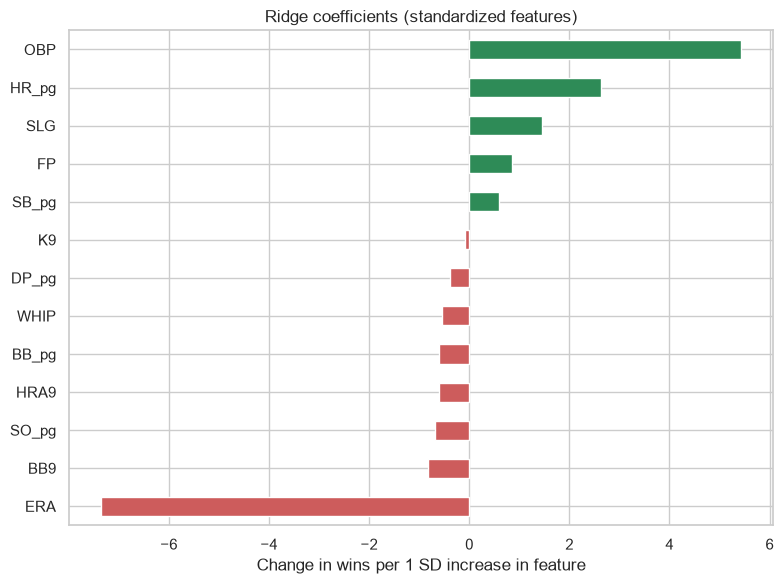

In [20]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    return {
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "MAE": mean_absolute_error(y, pred),
        "R2": r2_score(y, pred),
    }, pred

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50)))
ridge.fit(X_train, y_train)

ridge_scores, ridge_pred = evaluate("Ridge", ridge, X_test, y_test)
print("Chosen alpha:", round(ridge.named_steps["ridgecv"].alpha_, 3))
print({k: (round(v, 3) if not isinstance(v, str) else v) for k, v in ridge_scores.items()})

ridge_coefs = pd.Series(ridge.named_steps["ridgecv"].coef_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 6))
ridge_coefs.plot(kind="barh", color=["indianred" if c < 0 else "seagreen" for c in ridge_coefs])
plt.title("Ridge coefficients (standardized features)")
plt.xlabel("Change in wins per 1 SD increase in feature")
plt.tight_layout(); plt.show()

## 8. Model 2: Random Forest
**Two importance measures:**

*Impurity-based importance* is built into the model but can be biased toward correlated or high-variance features.

*Permutation importance* measures how much test performance drops when a feature is shuffled. It is generally more trustworthy with correlated features.

{'model': 'Random Forest', 'RMSE': np.float64(5.845), 'MAE': 4.534, 'R2': 0.794}


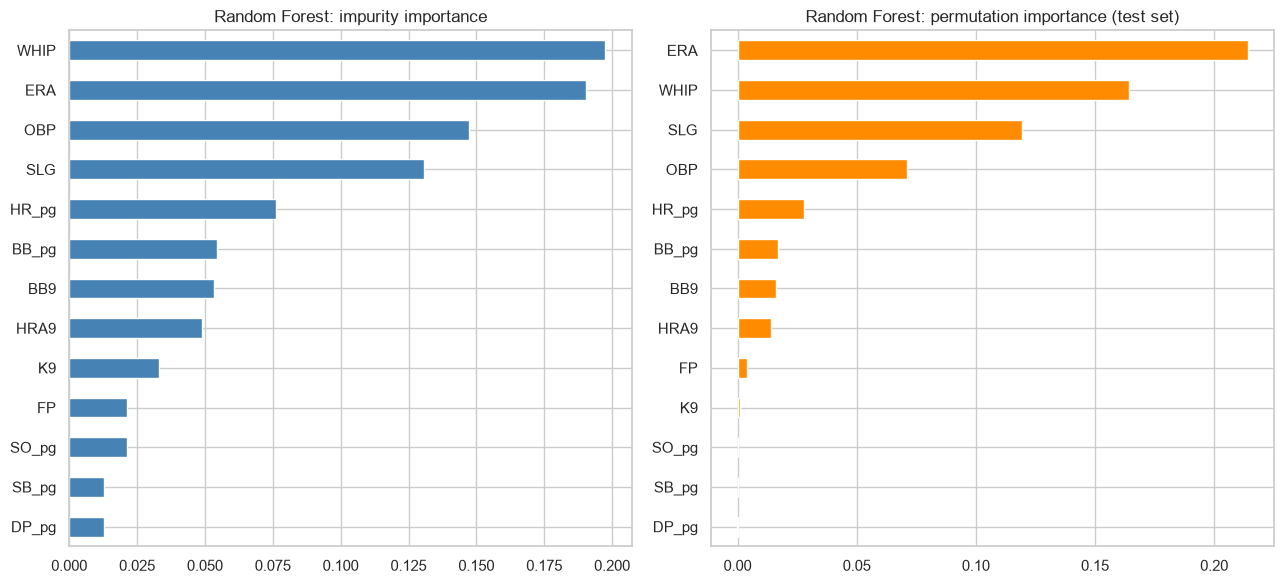

In [24]:
rf = RandomForestRegressor(
    n_estimators=500, min_samples_leaf=3, max_features="sqrt",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_scores, rf_pred = evaluate("Random Forest", rf, X_test, y_test)
print({k: (round(v, 3) if not isinstance(v, str) else v) for k, v in rf_scores.items()})

rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
rf_perm = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
rf_imp.plot(kind="barh", ax=axes[0], color="steelblue"); axes[0].set_title("Random Forest: impurity importance")
rf_perm.plot(kind="barh", ax=axes[1], color="darkorange"); axes[1].set_title("Random Forest: permutation importance (test set)")
plt.tight_layout(); plt.show()

## 9. Model Comparison

,RMSE,MAE,R2
model,,,
Ridge,5.387,4.307,0.825
Random Forest,5.845,4.534,0.794


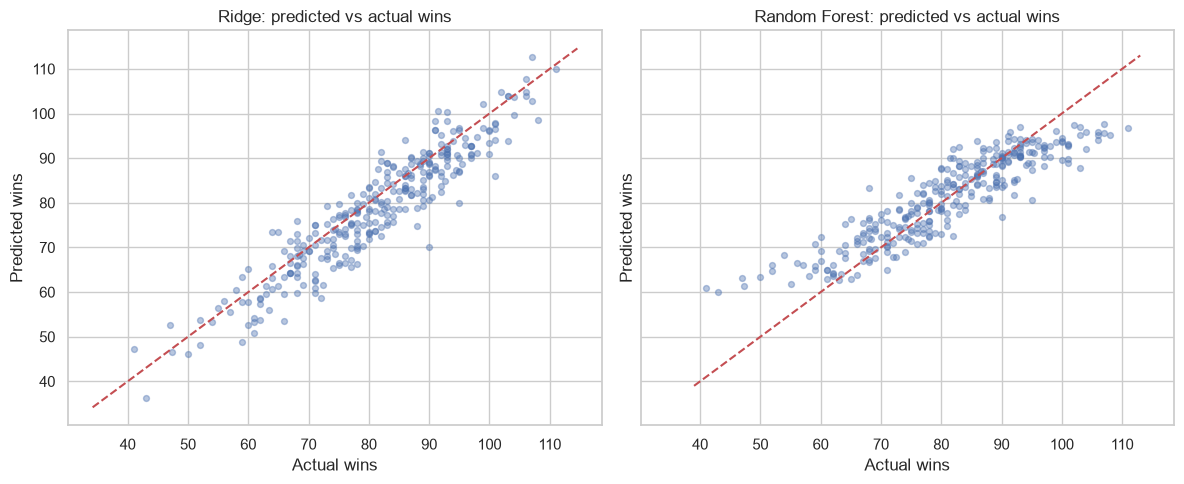

In [22]:
results = pd.DataFrame([ridge_scores, rf_scores]).set_index("model").round(3)
display(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pred, name in zip(axes, [ridge_pred, rf_pred], ["Ridge", "Random Forest"]):
    ax.scatter(y_test, pred, alpha=0.4, s=18)
    lims = [min(y_test.min(), pred.min()) - 2, max(y_test.max(), pred.max()) + 2]
    ax.plot(lims, lims, "r--")
    ax.set_title(f"{name}: predicted vs actual wins"); ax.set_xlabel("Actual wins"); ax.set_ylabel("Predicted wins")
plt.tight_layout(); plt.show()

,Ridge |coef|,RF impurity,RF permutation,group
ERA,1,2,1,Pitching
OBP,2,3,4,Offense
HR_pg,3,5,5,Offense
SLG,4,4,3,Offense
FP,5,10,9,Defense
BB9,6,7,7,Pitching
SO_pg,7,11,11,Offense
HRA9,8,8,8,Pitching
SB_pg,9,12,12,Offense
BB_pg,10,6,6,Offense


Rank agreement (Spearman):
                Ridge |coef|  RF impurity  RF permutation
Ridge |coef|            1.00         0.48            0.57
RF impurity             0.48         1.00            0.98
RF permutation          0.57         0.98            1.00


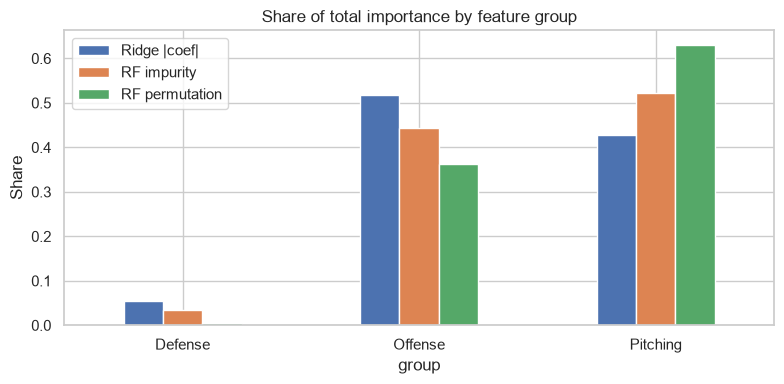

In [23]:
importance = pd.DataFrame({
    "Ridge |coef|": ridge_coefs.abs(),
    "RF impurity": rf_imp,
    "RF permutation": rf_perm,
})
ranks = importance.rank(ascending=False).astype(int)
ranks["group"] = ["Offense" if f in OFFENSE else "Pitching" if f in PITCHING else "Defense" for f in ranks.index]
ranks = ranks.sort_values("Ridge |coef|")
display(ranks)

print("Rank agreement (Spearman):")
print(importance.corr(method="spearman").round(2))

share = importance / importance.sum()
share["group"] = ranks["group"]
group_share = share.groupby("group").sum()
group_share.plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Share of total importance by feature group"); plt.ylabel("Share")
plt.tight_layout(); plt.show()